## Diabetes Prediction

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
diabetes_df = pd.read_csv('../data/diabetes.csv')

In [3]:
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
diabetes_df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [5]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
rows = diabetes_df.shape[0]
columns = diabetes_df.shape[1]

print(f'Rows - {rows}\nColumns - {columns}')

Rows - 768
Columns - 9


In [7]:
diabetes_df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

## Data cleaning

In [8]:
#Checking for nulls

diabetes_df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
#Checking for nulls

diabetes_df.isnull().sum().sum()

np.int64(0)

In [10]:
#Check for duplicates

print(diabetes_df.duplicated().sum())

0


In [11]:
diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Exploratory Data Analysis

In [12]:
corr_matrix = diabetes_df.corr()['Outcome']

In [13]:
corr_matrix

Pregnancies                 0.221898
Glucose                     0.466581
BloodPressure               0.065068
SkinThickness               0.074752
Insulin                     0.130548
BMI                         0.292695
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64

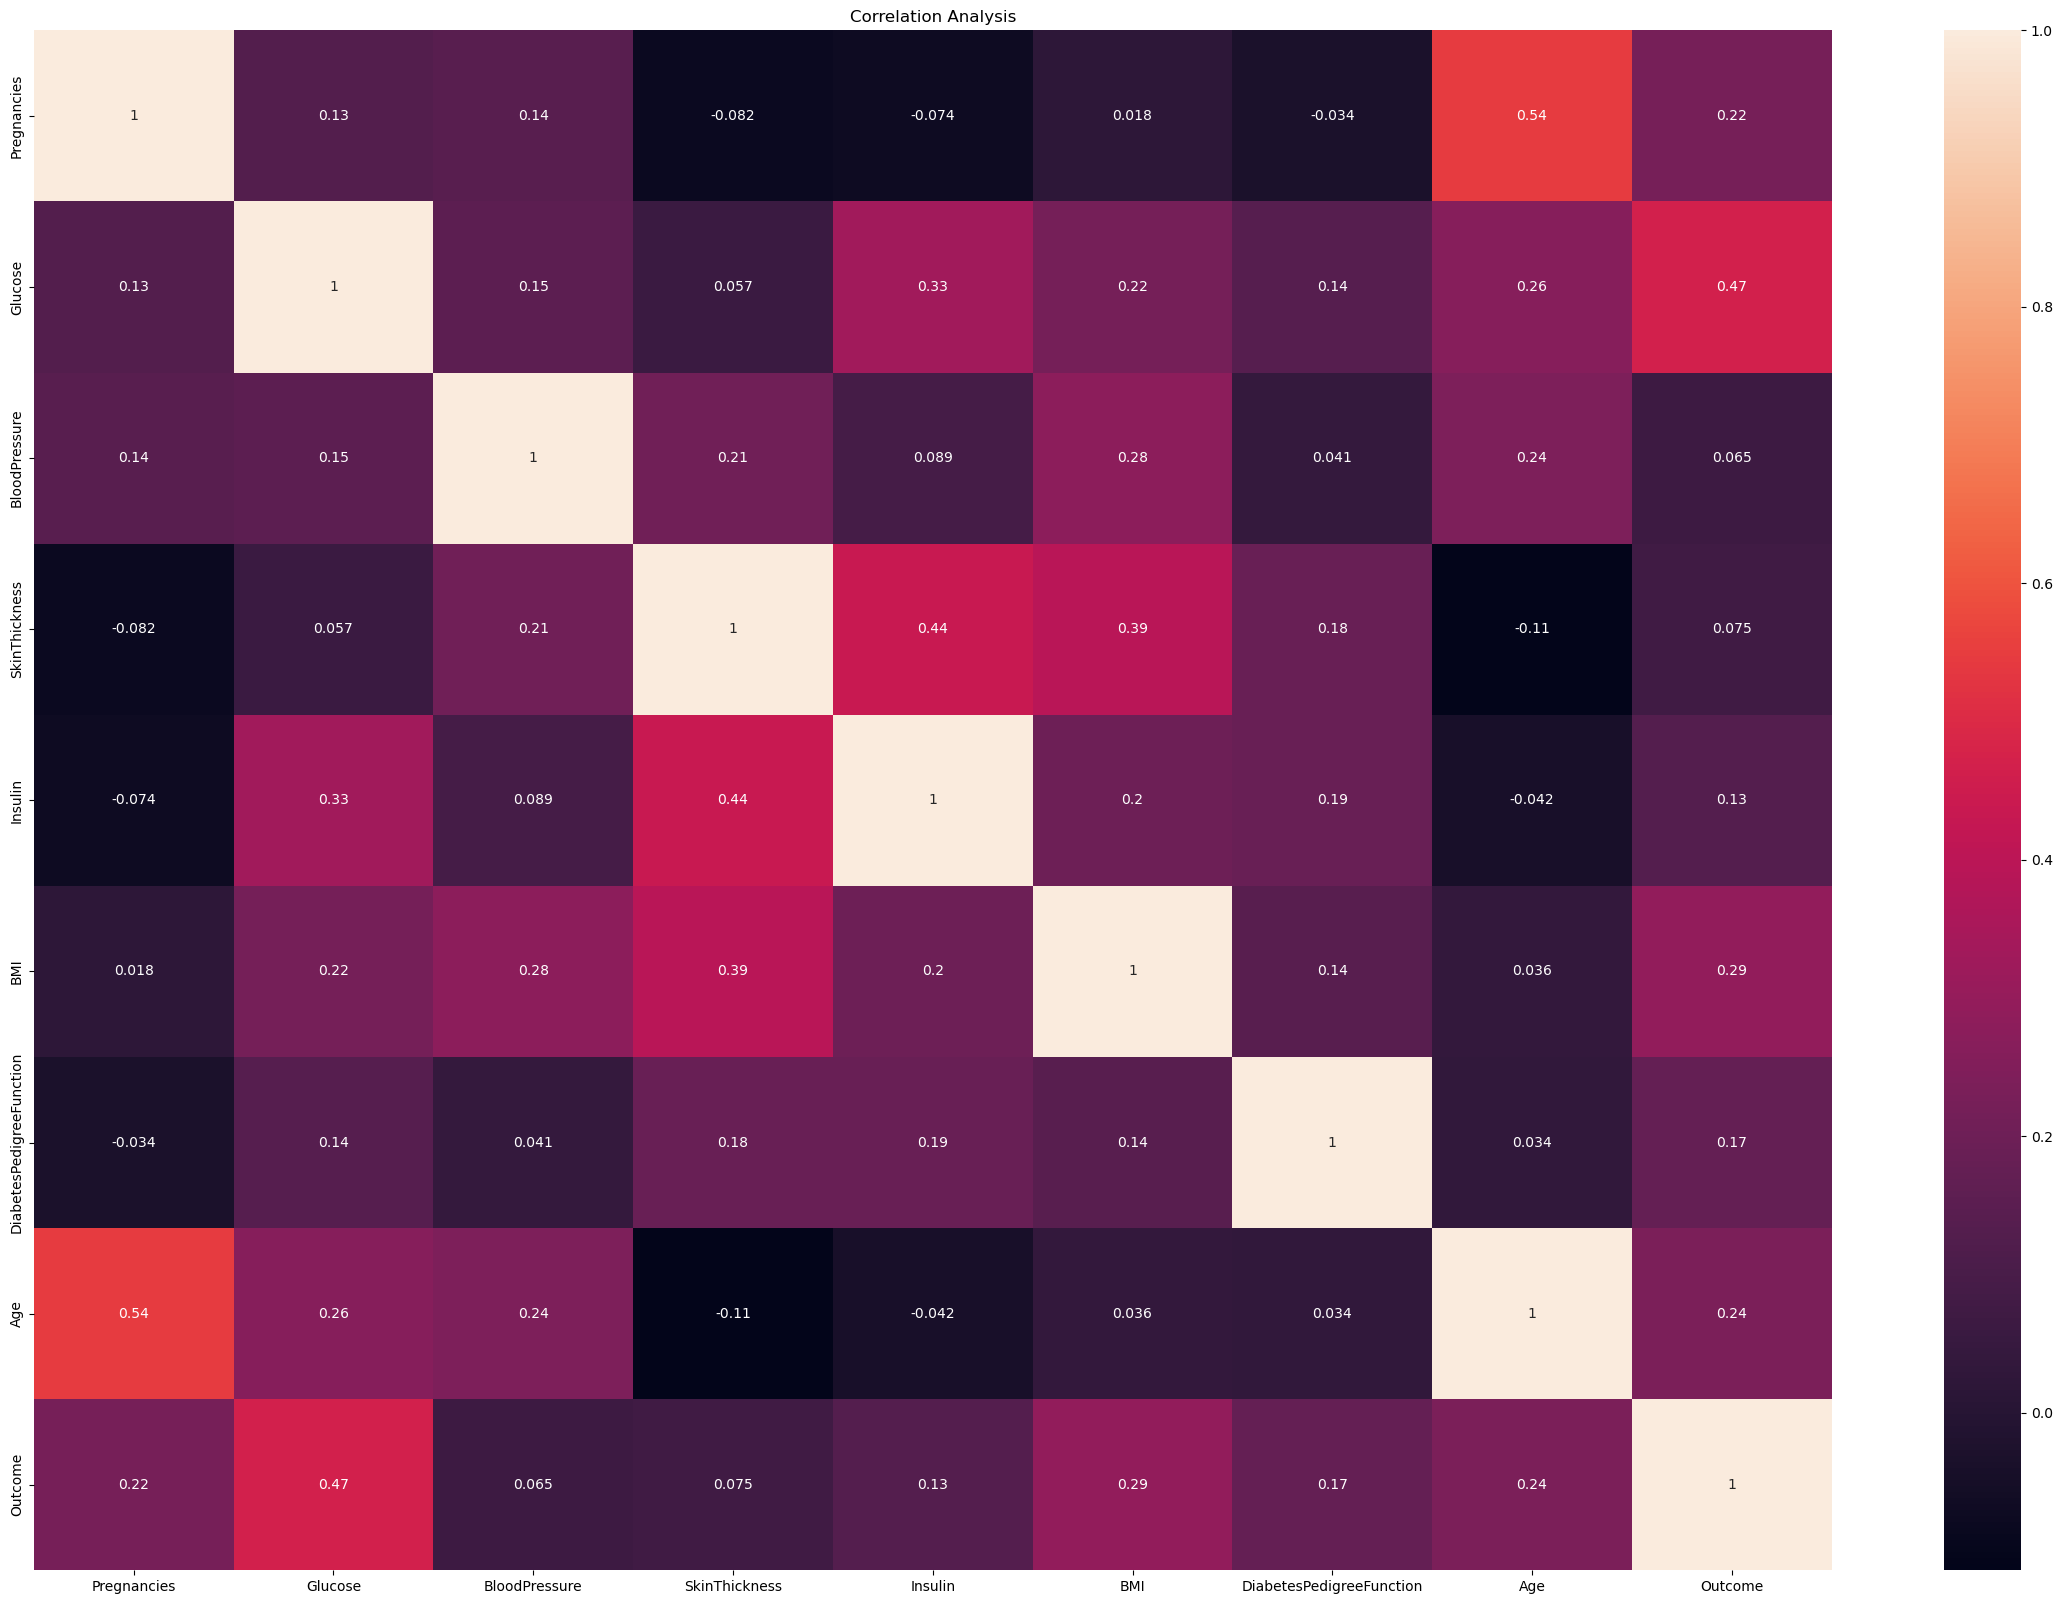

In [14]:
plt.figure(figsize = (29, 20))
sns.heatmap(data = diabetes_df.corr(), annot = True)
plt.title('Correlation Analysis')
plt.show()

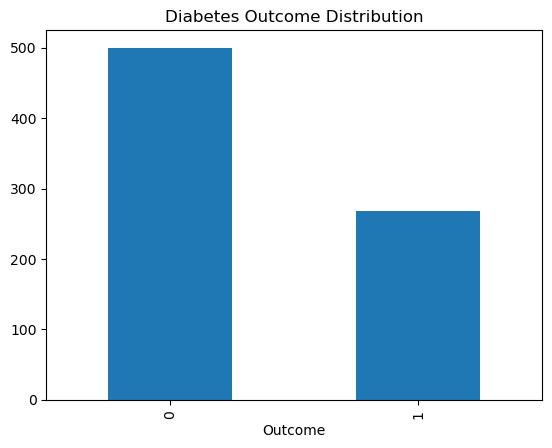

In [15]:
diabetes_df["Outcome"].value_counts().plot(kind="bar")
plt.title("Diabetes Outcome Distribution")
plt.show()

## Modeling

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

In [17]:
x = diabetes_df.drop('Outcome',axis=1)
y = diabetes_df['Outcome']

In [18]:
numeric_cols = x.select_dtypes(include = ['number']).columns.tolist()
categorical_cols = x.select_dtypes(include = ['object']).columns.tolist()


In [19]:
numeric_cols

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [20]:
categorical_cols

[]

## Pipeline

In [21]:
numeric_pipeline = Pipeline(steps=[('numericPipeline', StandardScaler())])
categorical_pipeline = Pipeline(steps = [('categoricalPipeline', OneHotEncoder(handle_unknown = 'ignore'))])

In [22]:
from sklearn.compose import ColumnTransformer

In [23]:
# Preprocessing Pipeline
ml_preprocess = ColumnTransformer(

    transformers = [

        ('TransformNumeric', numeric_pipeline, numeric_cols),
        ('TransformCategory', categorical_pipeline, categorical_cols), 
    ]
    
)

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)

In [26]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import(
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix,
ConfusionMatrixDisplay,
classification_report
)

In [27]:
lr_model = Pipeline(steps=[
    ('preprocess', ml_preprocess),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [28]:
dt_model = Pipeline(steps=[
    ('preprocess', ml_preprocess),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [29]:
rf_model = Pipeline(steps=[
    ('preprocess', ml_preprocess),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [30]:
nb_model = Pipeline(steps=[
    ('preprocess', ml_preprocess),
    ('classifier', GaussianNB())
])

In [31]:
knn_model = Pipeline(steps=[
    ('preprocess', ml_preprocess),
    ('classifier', KNeighborsClassifier())
])

In [32]:
svm_model = Pipeline(steps=[
    ('preprocess', ml_preprocess),
    ('classifier', SVC(probability=True, random_state=42))
])

In [33]:
models = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Naive Bayes': nb_model,
    'KNN': knn_model, 
    'SVM': svm_model
}

## Training the models

In [ ]:
for name, model in models.items():
    model.fit(x_train, y_train)
    print(f"{name} trained successfully.")

In [ ]:
lr_model.fit(x_train, y_train)

In [ ]:
dt_model.fit(x_train, y_train)

In [ ]:
rf_model.fit(x_train, y_train)

In [ ]:
nb_model.fit(x_train, y_train)

In [ ]:
knn_model.fit(x_train, y_train)

In [ ]:
svm_model.fit(x_train, y_train)

## Testing the models

In [ ]:
lr_y = lr_model.predict(x_test)
dt_y = dt_model.predict(x_test)
rf_y = rf_model.predict(x_test)
nb_y = nb_model.predict(x_test)
knn_y = knn_model.predict(x_test)
svm_y = svm_model.predict(x_test)

## Performance Evaluation

In [ ]:
y_test.value_counts()

In [ ]:
results = []

for name, model in models.items():

    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 score': f1
    })

    print('=' * 60)
    print(name)
    print('=' * 60)
    print(classification_report(y_test, y_pred))

In [ ]:
results_df = pd.DataFrame(results)

results_df.sort_values(by='Accuracy', ascending=False)

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, lr_y)
plt.show()

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, dt_y)
plt.show()

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_y)
plt.show()

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, nb_y)
plt.show()

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, knn_y)
plt.show()

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, svm_y)
plt.show()

In [ ]:
best_model = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print(best_model)

In [ ]:
import joblib

joblib.dump(nb_model, '../Model/diabetes_prediction_pipeline.pkl')

In [ ]:
pipeline = joblib.load('../Model/diabetes_prediction_pipeline.pkl')